# Zajęcie 4 — Sieci neuronowe i CNN
**Wariant 9**

1. Optymalizacja funkcji **f(x) = x⁴ − 4x³ + 2** metodą spadku gradientu + wizualizacja
2. Sieć neuronowa do przewidywania **wartości ciągłych** (regresja) na sztucznych danych
3. **CNN** na zbiorze **MNIST**


## 1. Optymalizacja gradientowa: f(x) = x⁴ − 4x³ + 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Funkcja i jej pochodna
f = lambda x: x**4 - 4*x**3 + 2
grad_f = lambda x: 4*x**3 - 12*x**2   # f'(x) = 4x^3 - 12x^2 = 4x^2(x - 3) -> minimum w x=3

def gradient_descent(f, grad_f, theta_init, lr, iterations):
    theta = theta_init
    traj = [theta]
    for _ in range(iterations):
        theta = theta - lr * grad_f(theta)
        traj.append(theta)
    return theta, np.array(traj)

theta0 = 4.0  # punkt startowy (po prawej od minimum)
lr = 0.01
iters = 100

opt, traj = gradient_descent(f, grad_f, theta0, lr, iters)
print(f'Punkt startowy: {theta0}')
print(f'Optymalne theta: {opt:.4f}  (oczekiwane: 3.0)')
print(f'f(theta*) = {f(opt):.4f}     (oczekiwane: -25.0)')


Punkt startowy: 4.0
Optymalne theta: 3.0000  (oczekiwane: 3.0)
f(theta*) = -25.0000     (oczekiwane: -25.0)


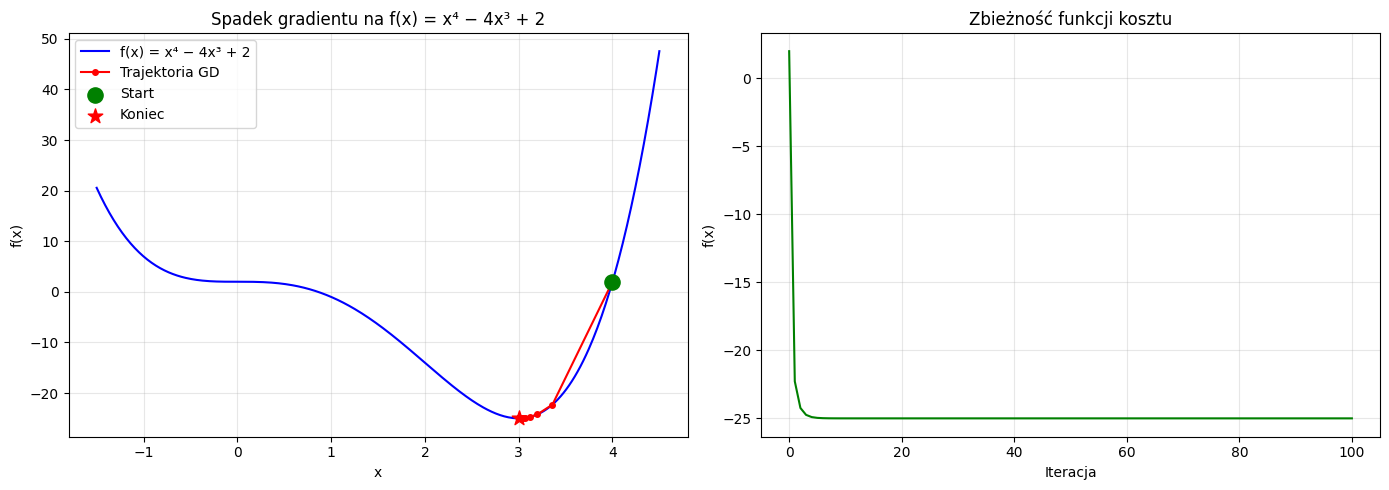

In [2]:
# Wizualizacja procesu optymalizacji
xs = np.linspace(-1.5, 4.5, 400)
ys = f(xs)

fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Wykres funkcji + trajektoria
ax[0].plot(xs, ys, 'b-', label='f(x) = x⁴ − 4x³ + 2')
ax[0].plot(traj, f(traj), 'ro-', markersize=4, label='Trajektoria GD')
ax[0].scatter([traj[0]], [f(traj[0])], color='green', s=120, zorder=5, label='Start')
ax[0].scatter([traj[-1]], [f(traj[-1])], color='red', s=120, marker='*', zorder=5, label='Koniec')
ax[0].set_xlabel('x'); ax[0].set_ylabel('f(x)')
ax[0].set_title('Spadek gradientu na f(x) = x⁴ − 4x³ + 2')
ax[0].legend(); ax[0].grid(alpha=0.3)

# Wartość funkcji w kolejnych iteracjach
ax[1].plot(f(traj), 'g-')
ax[1].set_xlabel('Iteracja'); ax[1].set_ylabel('f(x)')
ax[1].set_title('Zbieżność funkcji kosztu')
ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 2. Sieć neuronowa — regresja (wartości ciągłe) na sztucznych danych

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split

np.random.seed(42)
tf.random.set_seed(42)

# Sztuczne dane: y = sin(x1) + 0.5*x2^2 + szum
N = 1000
X = np.random.uniform(-3, 3, size=(N, 2))
y = np.sin(X[:,0]) + 0.5 * X[:,1]**2 + np.random.normal(0, 0.1, N)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model: sieć w pełni połączona, MSE
model = Sequential([
    Input(shape=(2,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                    validation_split=0.2, verbose=0)

# Ewaluacja
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f'Test MSE: {loss:.4f}')
print(f'Test MAE: {mae:.4f}')


Test MSE: 0.0237
Test MAE: 0.1225


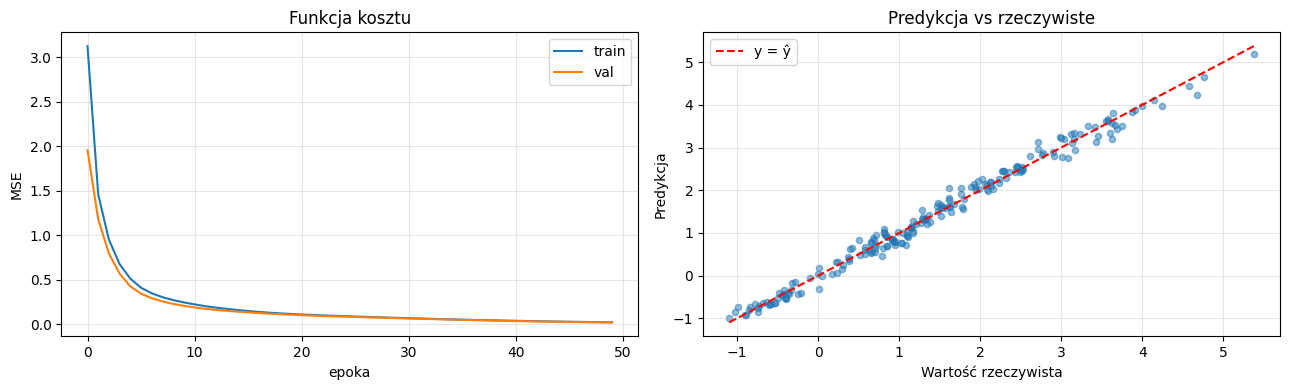

In [5]:
# Wykres uczenia
fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].plot(history.history['loss'], label='train')
ax[0].plot(history.history['val_loss'], label='val')
ax[0].set_xlabel('epoka'); ax[0].set_ylabel('MSE'); ax[0].set_title('Funkcja kosztu')
ax[0].legend(); ax[0].grid(alpha=0.3)

# Prognozowanie: porównanie wartości rzeczywistych z predykcją
y_pred = model.predict(X_test, verbose=0).flatten()
ax[1].scatter(y_test, y_pred, alpha=0.5, s=20)
ax[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='y = ŷ')
ax[1].set_xlabel('Wartość rzeczywista'); ax[1].set_ylabel('Predykcja')
ax[1].set_title('Predykcja vs rzeczywiste')
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 3. CNN — klasyfikacja MNIST

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 28, 28) Test: (10000, 28, 28)


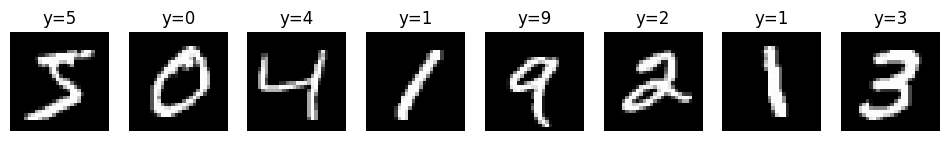

In [6]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Wczytanie zbioru MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print('Train:', X_train.shape, 'Test:', X_test.shape)

# Normalizacja i reshape
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test  = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_train_oh = to_categorical(y_train, 10)
y_test_oh  = to_categorical(y_test, 10)

# Podgląd przykładowych próbek
fig, axes = plt.subplots(1, 8, figsize=(12,2))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i].squeeze(), cmap='gray')
    ax.set_title(f'y={y_train[i]}')
    ax.axis('off')
plt.show()


In [7]:
# Architektura CNN
cnn = Sequential([
    Input(shape=(28,28,1)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Trening
hist = cnn.fit(X_train, y_train_oh, epochs=5, batch_size=128,
               validation_split=0.1, verbose=1)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.9026 - loss: 0.3261 - val_accuracy: 0.9793 - val_loss: 0.0685
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9702 - loss: 0.0983 - val_accuracy: 0.9868 - val_loss: 0.0481
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9779 - loss: 0.0738 - val_accuracy: 0.9892 - val_loss: 0.0416
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9827 - loss: 0.0590 - val_accuracy: 0.9887 - val_loss: 0.0395
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9852 - loss: 0.0488 - val_accuracy: 0.9902 - val_loss: 0.0345


Test loss: 0.0319
Test accuracy: 0.9895


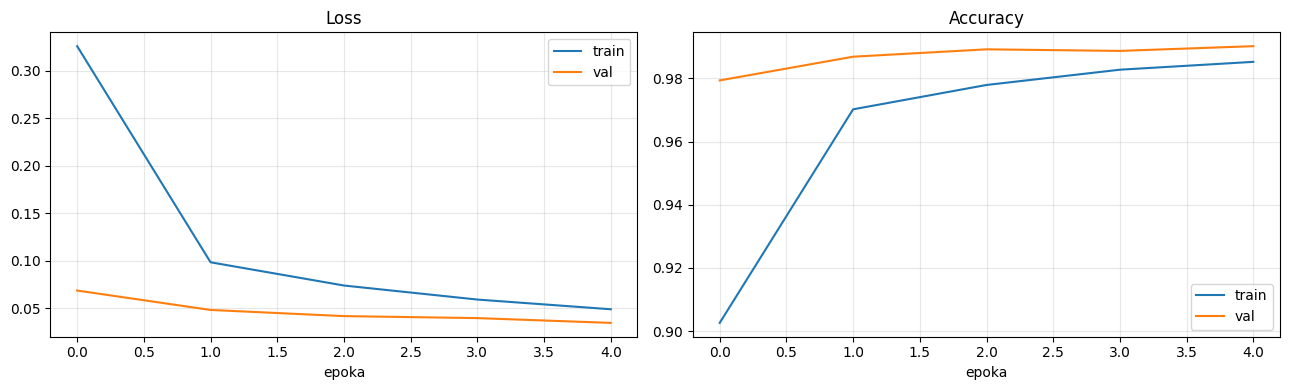

In [9]:
# Ewaluacja
test_loss, test_acc = cnn.evaluate(X_test, y_test_oh, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

# Wykresy uczenia
fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].plot(hist.history['loss'], label='train')
ax[0].plot(hist.history['val_loss'], label='val')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoka'); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(hist.history['accuracy'], label='train')
ax[1].plot(hist.history['val_accuracy'], label='val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('epoka'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


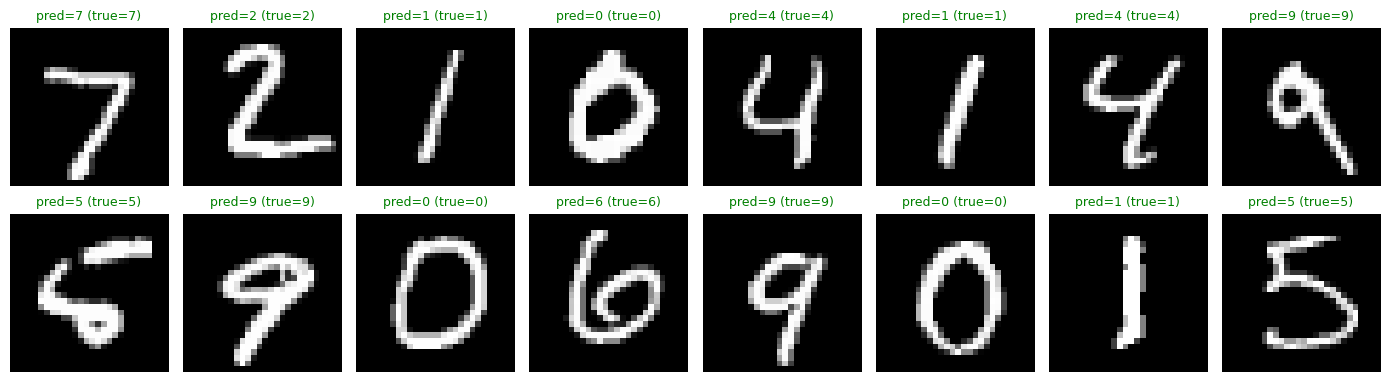

In [10]:
# Prognozowanie — przykłady z predykcją CNN
y_pred = cnn.predict(X_test[:16], verbose=0).argmax(axis=1)

fig, axes = plt.subplots(2, 8, figsize=(14,4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_test[i].squeeze(), cmap='gray')
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    ax.set_title(f'pred={y_pred[i]} (true={y_test[i]})', color=color, fontsize=9)
    ax.axis('off')
plt.tight_layout(); plt.show()


## Wnioski

- **GD**: dla f(x) = x⁴ − 4x³ + 2 algorytm zbiega do minimum lokalnego x = 3 (f = −25). Punkt startowy ma znaczenie — start z x < 0 może zatrzymać się w punkcie siodłowym x=0 (f'(0)=0, ale to nie minimum).
- **Sieć regresyjna**: w pełni połączona sieć z MSE skutecznie aproksymuje nieliniową funkcję; krzywa val_loss spada i stabilizuje się.
- **CNN na MNIST**: prosta architektura (2 warstwy konwolucyjne + pooling + dense) osiąga ~99% dokładności na zbiorze testowym po kilku epokach.
